In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from matplotlib.patches import Circle

# Plotting on map

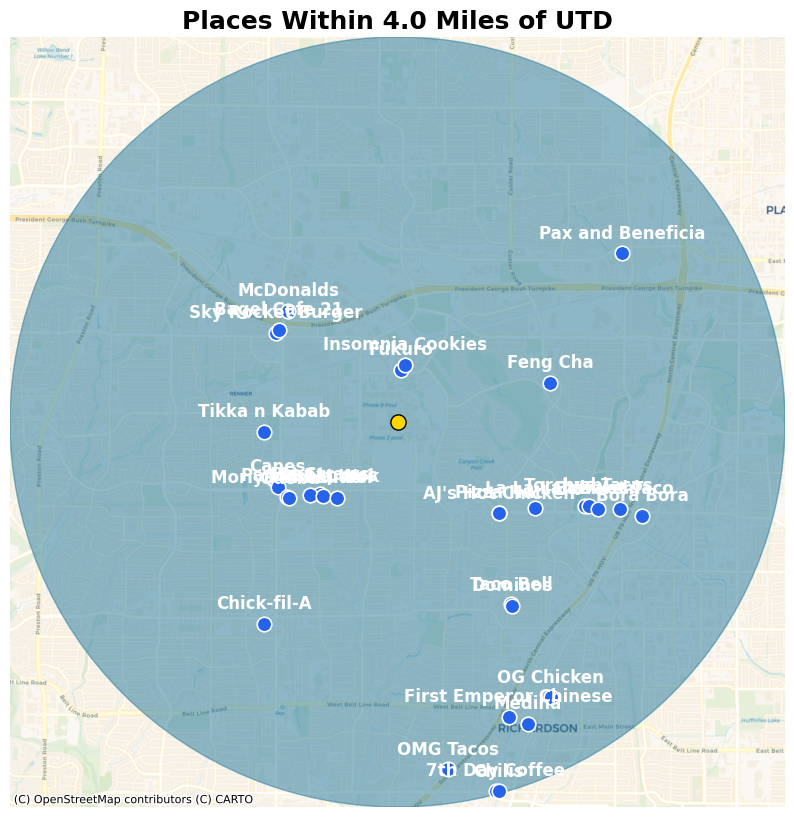

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from matplotlib.patches import Circle
import math

# ---------------------------
# Restaurant Data
# ---------------------------
places = [
    {"name": "OMG Tacos", "lat": 32.94293694851955, "lon": -96.74319803462491},
    {"name": "OG Chicken", "lat": 32.952038661932946, "lon": -96.72781425689165},
    {"name": "Bora Bora", "lat": 32.97495864551868, "lon": -96.71411295923134},
    {"name": "Velvet Taco", "lat": 32.97585386071342, "lon": -96.71737771382224},
    {"name": "Junbi", "lat": 32.97622194776941, "lon": -96.72264872905316},
    {"name": "Pax and Beneficia", "lat": 33.008181734889476, "lon": -96.71714085257634},
    {"name": "7th Day Coffee", "lat": 32.940228639939455, "lon": -96.73602231645798},
    {"name": "Torchys Tacos", "lat": 32.97625399866999, "lon": -96.72209788845961},
    {"name": "Canes", "lat": 32.978658122294284, "lon": -96.76865638916519},
    {"name": "Feng Cha", "lat": 32.99177272871219, "lon": -96.72787932902152},
    {"name": "Chick-fil-A", "lat": 32.96133884221472, "lon": -96.77073096217347},
    {"name": "Fat Straws", "lat": 32.97770804072288, "lon": -96.76230941906651},
    {"name": "Sky Rocket Burger", "lat": 32.99811162230038, "lon": -96.76894198811675},
    {"name": "Medina", "lat": 32.94871302819809, "lon": -96.7312299983803},
    {"name": "First Emperor Chinese", "lat": 32.94960057528753, "lon": -96.73408773158921},
    {"name": "Moriya Shokudo", "lat": 32.97733218519953, "lon": -96.76730059852501},
    {"name": "Fukuro", "lat": 32.993427048731235, "lon": -96.7501837295768},
    {"name": "McDonalds", "lat": 33.00085944660266, "lon": -96.76708058662895},
    {"name": "Qdoba", "lat": 32.97719, "lon": -96.76691},
    {"name": "AJ's Hot Chicken", "lat": 32.97531, "lon": -96.73548},
    {"name": "Bawarchi", "lat": 32.97589, "lon": -96.72078},
    {"name": "Taco Bell", "lat": 32.96377, "lon": -96.73375},
    {"name": "La La Land", "lat": 32.97595, "lon": -96.73015},
    {"name": "Panda Express", "lat": 32.97758, "lon": -96.76389},
    {"name": "Masala Wok", "lat": 32.97744, "lon": -96.76184},
    {"name": "Insomnia Cookies", "lat": 32.9940610405489, "lon": -96.74959673553462},
    {"name": "Pei Wei", "lat": 32.97724, "lon": -96.75972},
    {"name": "Bagel Cafe 21", "lat": 32.99849, "lon": -96.7685},
    {"name": "Chilis", "lat": 32.94014, "lon": -96.73556},
    {"name": "Pizza Hut", "lat": 32.97535, "lon": -96.73551},
    {"name": "Tikka n Kabab", "lat": 32.98557, "lon": -96.77072},
    {"name": "Dominos", "lat": 32.96362, "lon": -96.73363},
]

# ---------------------------
# Center (UTD)
# ---------------------------
center_lon, center_lat = -96.75072866286929, 32.98683820680625

campus = gpd.GeoDataFrame(
    geometry=[Point(center_lon, center_lat)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# ---------------------------
# Dynamic radius
# ---------------------------
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

max_dist = max(haversine(center_lat, center_lon, p["lat"], p["lon"]) for p in places)
radius = max_dist * 1.2
miles = radius / 1609

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(10, 10))

circle_geom = campus.buffer(radius)
minx, miny, maxx, maxy = circle_geom.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=14)

# darker circle
circle = Circle(
    (campus.geometry.x.iloc[0], campus.geometry.y.iloc[0]),
    radius,
    color="#21779c",   # brighter blue
    alpha=0.5,         # 👈 darker than before
    zorder=2
)
ax.add_patch(circle)

# UTD point
ax.scatter(
    campus.geometry.x,
    campus.geometry.y,
    s=120,
    color="gold",
    edgecolor="black",
    zorder=4
)

# restaurants
for p in places:
    point = gpd.GeoSeries([Point(p["lon"], p["lat"])], crs="EPSG:4326").to_crs(epsg=3857)
    x = point.geometry.x.iloc[0]
    y = point.geometry.y.iloc[0]

    # bigger dots
    ax.scatter(
        x, y,
        s=110,
        color="#2563eb",
        edgecolor="white",
        linewidth=1.2,
        zorder=5
    )

    # white text, subtle box
    ax.text(
        x,
        y + 250,                 # more spacing above dot
        p["name"],
        fontsize=12,             # 👈 MUCH bigger
        fontweight='bold',
        ha='center',
        color="white",
        zorder=6
    )

# title
ax.set_title(f"Places Within {round(miles,1)} Miles of UTD",
             fontsize=18, fontweight="bold")

ax.set_axis_off()
plt.show()

C:\Users\Koolt\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


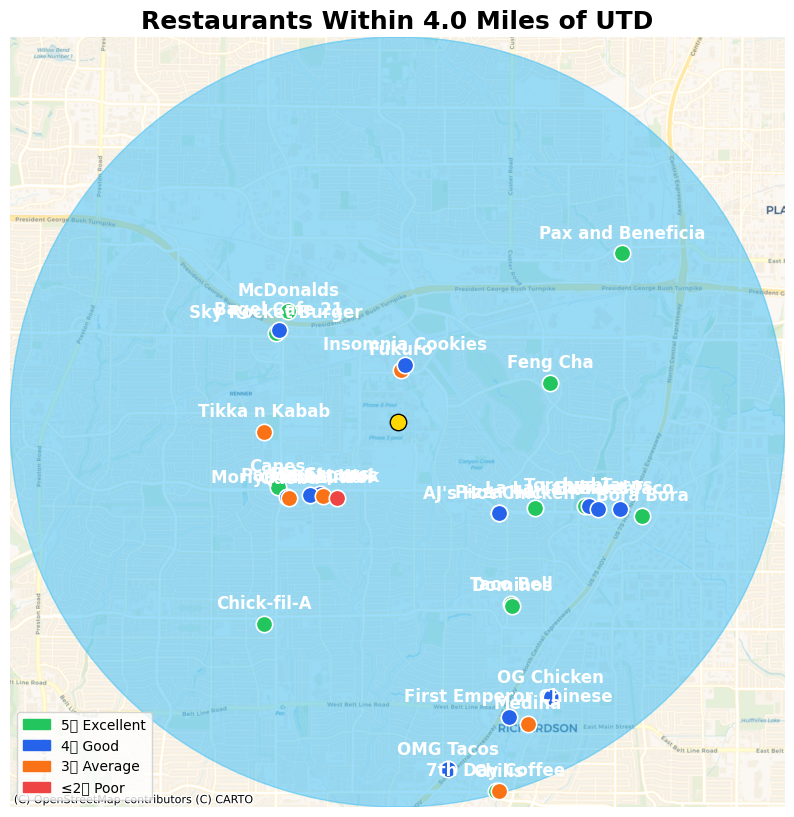

In [ ]:
 Pr